**<center><font size=5>Building a CNN architecture on our own Dataset</font></center>**

---

**Table of Contents**

- <a href='#intro'>1. Project Overview and Objectives</a>
  - <a href='#dataset'>1.1. Data Set Description</a>
  - <a href='#tumor'>1.2. What is Sign Language?</a>
- <a href='#env'>2. Setting up the Environment</a>
- <a href='#import'>3. Data Import and Preprocessing</a>
- <a href='#cnn'>4. Building the AI model</a>
- <a href='#cnn'>5. Model evaluation</a>
- <a href='#concl'>6. Testing the model</a>
- <a href='#concl'>7. Conclusion</a>


# Introduction

Hey I'm Yuba , I'm an AI engineer student And I'll try to share with you every single project that I work on even the small ones - because it's where you can start to actually learn and touch some of the well known DL Architecture - In this section we're gonna focus on CNN and how we can adapt it on our Dataset (personnalized one / pre-annotated ones) - This schema or lemme call it learning process is identical to my TP instructor (Madame Neila Houacine - who's by the way awsome) and I'll try to guide you through it and push you to get on your machine and actually start to just practice everything that you already know

REMINDER : I'm just a beginner and my purpose is to share with you what I learn on my daily life (currently) - and every single piece of code is built entirely by USTHB instructors , I just adapt it to my own tasks -


# <a href='#intro'>1. Project Overview and Objectives</a>

The main purpose of this project is to build a **Convolutional Neural Network (CNN)** capable of classifying alphabet characters represented in **sign language**.  
The model learns to recognize hand gestures corresponding to letters of the alphabet and predict the correct class based on image input.

---

## <a href='#dataset'>1.1. Data Set Description</a>

The **MNIST Sign Language Dataset** (often called **Sign Language MNIST**) is a computer vision dataset used to train machine learning models to recognize **hand gestures representing letters of the alphabet**.

It is inspired by the famous **MNIST dataset**, which is commonly used for handwritten digit recognition.

### Key Characteristics

- **Image Size:** 28 × 28 grayscale images
- **Classes:** 24 hand signs representing letters of the alphabet
- **Missing Letters:** J and Z (because these gestures require motion)
- **Content:** Hand gestures corresponding to letters in **American Sign Language (ASL)**
- **Goal:** Train models (often CNNs) to classify the hand sign correctly.

Each image contains a **hand forming a specific letter**, and the model learns to identify the corresponding letter based on the visual pattern.

### Why is this Dataset Useful for Deep Learning?

This dataset is commonly used to:

- Practice **image classification**
- Train **Convolutional Neural Networks (CNNs)**
- Learn **feature extraction from images**
- Explore **gesture recognition systems**

It serves as a good **intermediate step between the classic MNIST digit dataset and more complex real-world computer vision problems**.

---

## <a href='#tumor'>1.2. What is Sign Language? 🤟</a>

**Sign language** is a visual language primarily used by people who are **deaf or hard of hearing** to communicate.

Instead of spoken words, sign language uses:

- **Hand gestures**
- **Finger positions**
- **Facial expressions**
- **Body movements**

to convey meaning.

Each gesture can represent a **letter, word, or concept**. Just like spoken languages, sign languages have their own **grammar and structure**.

One of the most widely used systems is **American Sign Language (ASL)**.

In systems such as ASL, the **alphabet can be represented using specific hand shapes**, allowing users to spell words letter by letter using hand gestures.


# <a id='intro'>2. Setting up the Environment: Import Statements</a>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# <a id='intro'>3(a) Data Import</a>

# <a id='intro'>3(b) Data Processing</a>

- I extracted the two phases just to gain some space


When working on different projects, you will need to load a different dataset. The best way to load a dataset is as follows:

(a) Upload the dataset to Google Drive

(b) The image path will be `/content/drive/My Drive/name_of_your_dataset`

Or if you're in your local machine , just install it and use it like I'm doing bellow , but if you encounter any storage problem just work in GOOGLE COLAB


In [ ]:
dataset_path = ".../sign-language-mnist"

train_df = pd.read_csv(
    f"{dataset_path}/sign_mnist_train.csv"
)  # Uploading the train dataset
y_train = train_df["label"].values
X_train = train_df.drop("label", axis=1).values

X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print(f"\n✅ X_train : {X_train.shape}")


✅ X_train : (27455, 28, 28, 1)


In [3]:
dataset_path = "E:/TP_RESN/TP3/sign-language-mnist"

train_df = pd.read_csv(f"{dataset_path}/sign_mnist_test.csv")
y_test = train_df["label"].values
X_test = train_df.drop("label", axis=1).values

X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print(f"\n✅ X_test : {X_test.shape}")


✅ X_test : (7172, 28, 28, 1)


In [4]:
print(f"✅ Classes présentes : {np.unique(y_train)}")

✅ Classes présentes : [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


In [5]:
X_train.shape  # see the 4th axis added

(27455, 28, 28, 1)

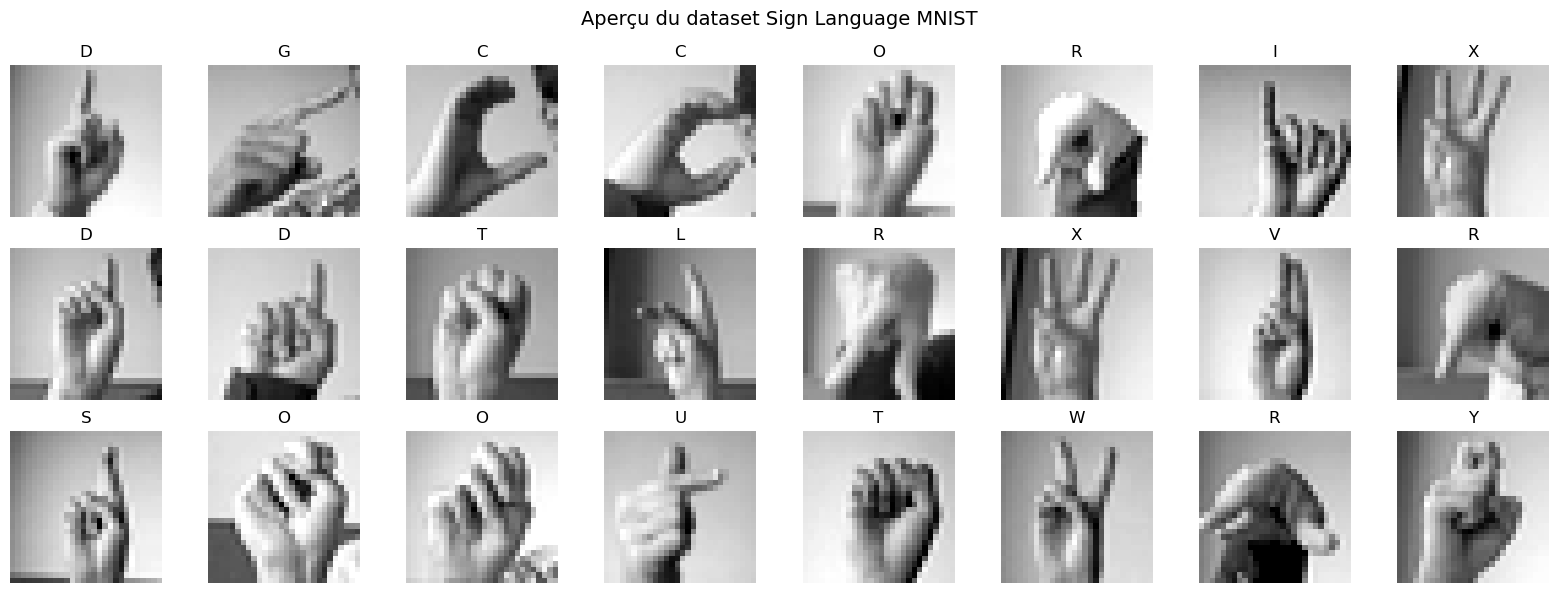

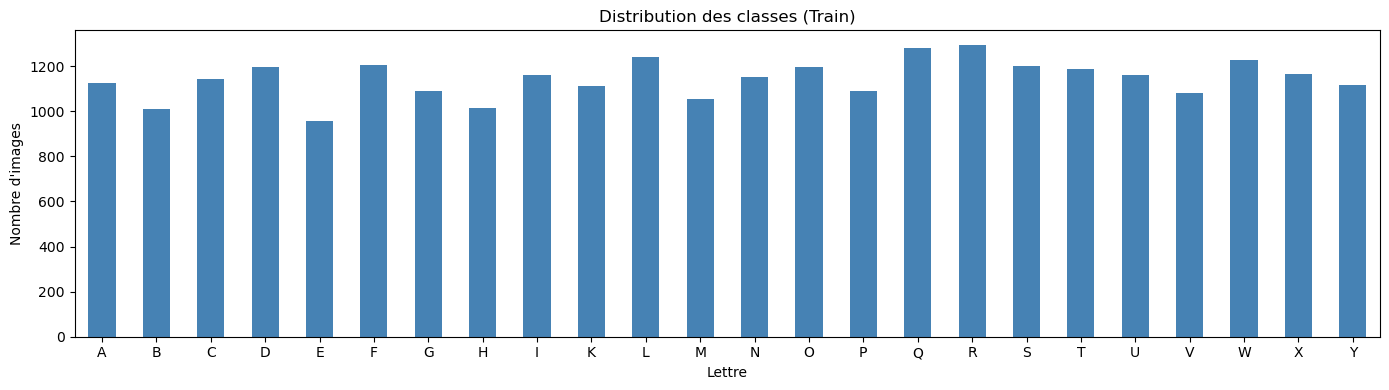


✅ Preprocessing terminé — prêt pour le modèle !
   X_train : (27455, 28, 28, 1) | y_train : (27455,)
   X_test  : (7172, 28, 28, 1)  | y_test  : (7172,)


In [7]:
# ── 5. Visualiser quelques exemples ──────────────────────────────────────────
labels_map = list("ABCDEFGHIKLMNOPQRSTUVWXY")  # J et Z exclus (mouvements)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(labels_map[y_train[i]], fontsize=12)
    ax.axis("off")
plt.suptitle("Aperçu du dataset Sign Language MNIST", fontsize=14)
plt.tight_layout()
plt.show()

# ── 6. Vérifier la distribution des classes ───────────────────────────────────
plt.figure(figsize=(14, 4))
pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.xticks(ticks=range(24), labels=labels_map, rotation=0)
plt.title("Distribution des classes (Train)")
plt.xlabel("Lettre")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

print("\n✅ Preprocessing terminé — prêt pour le modèle !")
print(f"   X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"   X_test  : {X_test.shape}  | y_test  : {y_test.shape}")

# <a id='intro'>4. Building the AI model</a>


## <a id='dataset'>4.1. Model Description</a>

In this step, we are constructing an AI model that uses a Convolutional Neural Network (CNN), which is particularly good for image recognition tasks. Our model begins with two convolutional layers that have 32 filters each; these layers are designed to detect basic patterns in the sign language images, like edges and textures.

## <a id='dataset'>4.2 Batch normalization</a>

We apply batch normalization after the convolutional layers to accelerate training by scaling the outputs to a standard range.

## <a id='dataset'>4.3 Pooling</a>

Next, we introduce a pooling layer to reduce the dimensionality of the data, which helps the model to focus on the important features, and a dropout layer to prevent overfitting, which is when the model learns the training data too well and performs poorly on new data. We repeat this pattern of convolutional, batch normalization, pooling, and dropout layers with 64 filters in the convolutional layers to capture more complex patterns.

## <a id='dataset'>4.4 Fully connected layer</a>

After processing through these layers, the data is flattened into a one-dimensional array so it can be fed into densely connected layers, which will make the final decisions about what the patterns represent – in our case, whether there is a tumor or not.

## <a id='dataset'>4.5 Activation function and optimizer</a>

The last dense layer uses softmax activation to output probabilities for each class, which completes our model architecture. We compile the model with a categorical crossentropy loss function, which is suitable for multi-class classification problems, and choose the Adamax optimizer, an adaptation of the Adam optimizer that is designed to work well with models that have embeddings and sparse data.

<img src="https://www.mdpi.com/axioms/axioms-10-00139/article_deploy/html/images/axioms-10-00139-g001.png" alt="CNN Architecture" width="700"/>

> _Schematic diagram of a Convolutional Neural Network (CNN): starting with an input image, the network applies multiple convolutional layers to detect features, interspersed with subsampling (pooling) layers to reduce dimensionality, and culminates in fully connected layers that lead to the final output classification_

Source: [MDPI](https://www.mdpi.com/2075-1680/10/3/139)

<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2020/10/90650dnn2.webp" alt="CNN Architecture - OURS" width="700"/>
> _Schematic diagram of a Convolutional Neural Network (CNN) - We already worked on this dataset (MNIST NUMBERS FROM HANDWRITTEN MANUSCRIPT): starting with an input image, the network applies multiple convolutional layers to detect features WITH DIFFERENT FILTERS, interspersed with subsampling (pooling) layers to reduce dimensionality layer by layer we play with the number of filters, and culminates in fully connected layers of course after the flattening process to have a 1D result (PS: THE FULLY CONNECTED LAYERS DEALS ONLY WITH 1D VECTORS - AND THAT WHY CNN IS HERE ) that lead to the final output classification_

Source: [analyticsvidhya](https://www.analyticsvidhya.com/blog/2020/10/what-is-the-convolutional-neural-network-architecture/)


In [ ]:
model = keras.Sequential(
    [
        # Block 1
        keras.layers.Conv2D(
            32, (3, 3), activation="relu", input_shape=(28, 28, 1), padding="same"
        ),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Dropout(0.25),
        # Block 2
        keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Dropout(0.25),
        # Block 3
        keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        # Dense
        keras.layers.Flatten(),
        keras.layers.Dense(256, activation="relu", kernel_initializer="he_normal"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),
        # Output — 24 classes (pas 25 !)
        keras.layers.Dense(25, activation="softmax"),
    ]
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

c:\Users\OMEN\miniconda3\envs\TS_Model\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# <a id='intro'>5. Model evaluation</a>

## <a id='intro'>5.1 What does the training process mean?</a>

This section is the training process of a machine learning model using a Convolutional Neural Network (CNN) architecture. The training is set to run for 8 epochs, which means the model will have 8 complete passes through the entire training dataset. During each epoch, the model learns by adjusting its weights to minimize the difference between its predictions and the actual data.

The batch size is set to 64 , indicating that the model will use 64 images at a time to update its weights. validation loss (the same measure, but calculated using a separate set of data not used in training) after each epoch.

From the output, we can see that as the epochs progress, both the training loss and the validation loss generally decrease, which suggests that the model is learning and improving its predictions on both the training and validation datasets. This output is crucial for monitoring the training process and determining if and when the model is ready for evaluation or deployment.


In [25]:
# Training
history = model.fit(X_train, y_train, epochs=8, batch_size=64, validation_split=0.1)

Epoch 1/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7956 - loss: 0.6907 - val_accuracy: 0.6271 - val_loss: 1.3429
Epoch 2/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9752 - loss: 0.0917 - val_accuracy: 0.9996 - val_loss: 0.0088
Epoch 3/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9925 - loss: 0.0353 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 4/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9955 - loss: 0.0227 - val_accuracy: 1.0000 - val_loss: 5.6965e-04
Epoch 5/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9979 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 5.9696e-04
Epoch 6/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9972 - loss: 0.0129 - val_accuracy: 0.9978 - val_loss: 0.0092
Epoch 7/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9972 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 6.1602e-04
Epoch 8/8
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9979 - loss: 0.0098 - val

In [26]:
# prediction
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


## <a id='intro'>5.3 Plotting losses</a>

The plot shows the model's loss on the test set and the validation set over the course of training epochs. The 'loss' refers to the value that a machine learning model tries to minimize during training. In this context, 'test loss' typically would refer to the loss calculated on a separate test set that is not used during the training process, whereas 'validation loss' refers to the loss calculated on a validation set, which is used to monitor and tune the model's performance during training.

In the plot shown, after an initial sharp decline, both losses decrease and tend to converge as the epochs increase, which suggests that the model is learning and generalizing well.


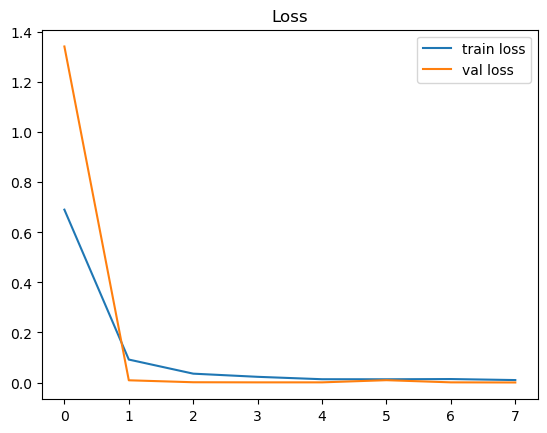

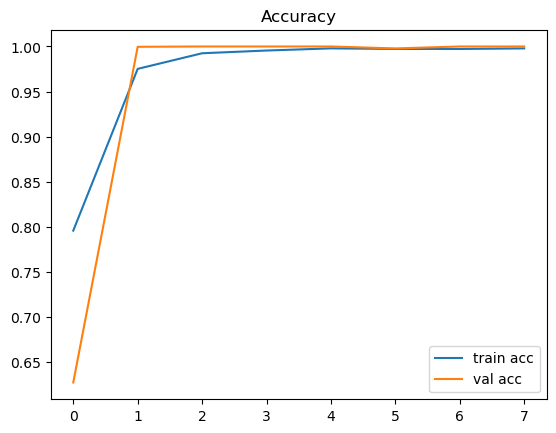

In [28]:
# Learning plots
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

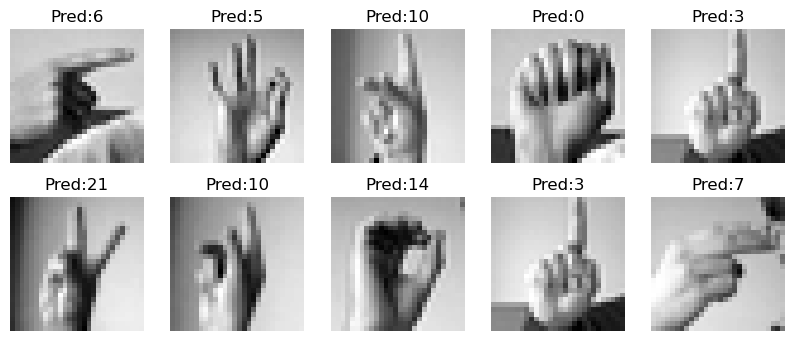

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred:{y_pred[i]}")
    ax.axis("off")

plt.show()

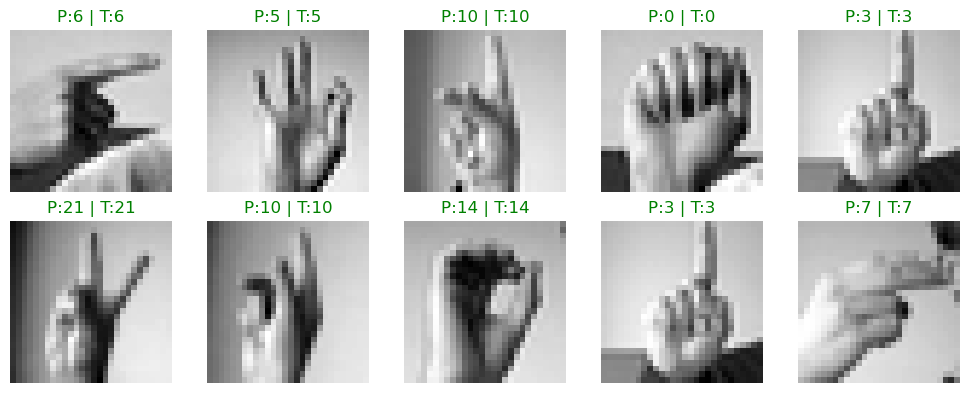

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")

    pred = y_pred[i]
    true = y_test[i]

    color = "green" if pred == true else "red"
    ax.set_title(f"P:{pred} | T:{true}", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9586 - loss: 0.1284
Test Accuracy : 95.86%
Test Loss     : 0.1284


## Model Performance Summary

### Final Results of the Model

| Dataset            | Accuracy | Loss   |
| ------------------ | -------- | ------ |
| **Training Set**   | 99.7%    | 0.009  |
| **Validation Set** | 100%     | 0.0001 |
| **Test Set**       | 95.86%   | 0.1284 |

### Interpretation of the Results

The small difference between **training accuracy (99.7%)** and **test accuracy (95.86%)** is expected.

The **test dataset contains hand images with slightly different angles, lighting conditions, and variations** compared to the training dataset.

This gap does **not indicate overfitting**. Instead, it reflects the natural variability that occurs in **real-world data**.

In practical computer vision applications, models must generalize to images that are not identical to the training data, and a slight drop in performance on the test set is therefore normal.


In [34]:
print("Labels uniques :", sorted(np.unique(y_test)))
print("Nombre de classes :", len(np.unique(y_test)))

Labels uniques : [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Nombre de classes : 24


## <a id='intro'>5.3 Plotting CONFUSION MATRIX</a>


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           A       0.97      1.00      0.98       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       0.95      1.00      0.98       498
           F       1.00      1.00      1.00       247
           G       0.94      0.97      0.96       348
           H       0.98      0.95      0.97       436
           I       0.93      0.96      0.95       288
           K       1.00      0.94      0.97       331
           L       0.91      1.00      0.95       209
           M       0.90      0.93      0.91       394
           N       0.98      0.82      0.89       291
           O       1.00      1.00      1.00       246
           P       0.98      1.00      0.99       347
           Q       1.00      1.00      1.00       164
           R       0.81      0.84      0

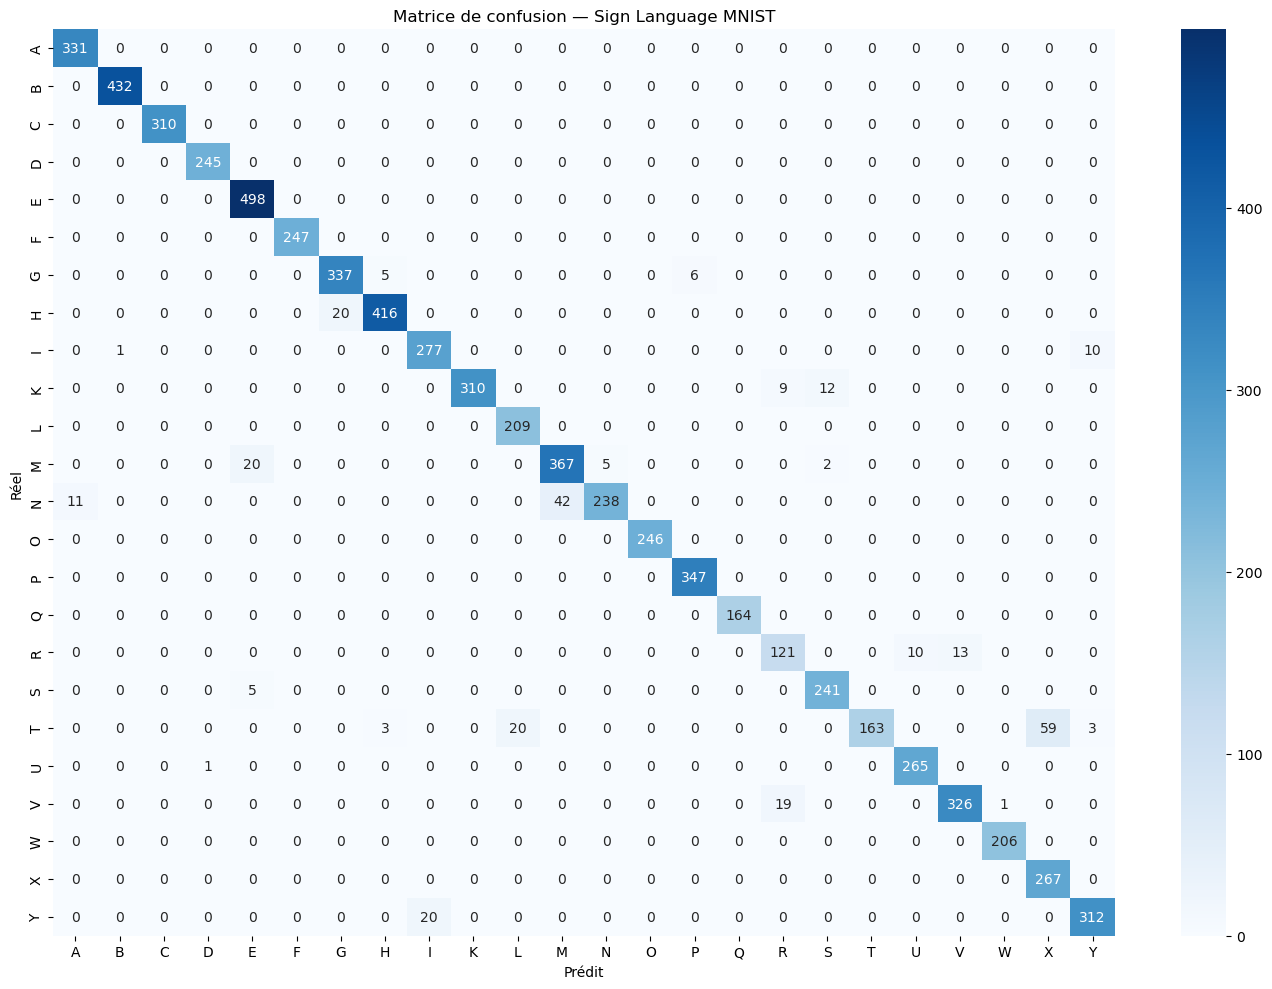

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import string

# Mapping correct : label = position dans l'alphabet (J=9 et Z=25 absents)
full_alphabet = list(string.ascii_uppercase)  # A=0, B=1, ..., Z=25
unique_labels = sorted(np.unique(y_test))
label_names = [full_alphabet[i] for i in unique_labels]  # label 10 → 'K' ✅

y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification report avec lettres
print(classification_report(y_test, y_pred, target_names=label_names))

# Matrice de confusion avec lettres
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Matrice de confusion — Sign Language MNIST")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()